# Hybrid Parameter Sweeps — Tuning a Multi-Subnetwork Model

This notebook demonstrates how to use the **unified `sweep()` API** to tune
coupling parameters in a multi-subnetwork brain model.  We build a
cortex + thalamus network and sweep the inter-subnetwork coupling strength to
find the boundary where the thalamus transitions from a quiescent fixed
point to noise-driven oscillations.

## What you'll learn
- Build a two-subnetwork hybrid model (JansenRit cortex + FHN thalamus)
- Sweep coupling parameters with named keys (`"coupling_scale"`)
- Compare CPU sequential, CPU multi-core, and GPU sweep performance
- Visualize the phase diagram: coupling strength vs oscillation amplitude

**Prerequisites:** TVB Hybrid + Numba backends installed.  GPU results
require a CUDA-capable NVIDIA GPU and `numba.cuda`.

## 1. Imports and data loading

In [1]:
import numpy as np
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tvb.datatypes.connectivity import Connectivity
from tvb.simulator.hybrid.subnetwork import Subnetwork
from tvb.simulator.hybrid.intra_projection import IntraProjection
from tvb.simulator.hybrid.inter_projection import InterProjection
from tvb.simulator.hybrid.coupling import Linear
from tvb.simulator.hybrid.network import NetworkSet
from tvb.simulator.integrators import HeunDeterministic
from tvb.simulator.models.jansen_rit import JansenRit
from tvb.simulator.models.stefanescu_jirsa import ReducedSetFitzHughNagumo
from tvb.simulator.backend.nb_hybrid import NbHybridBackend

DT = 0.1         # integration time step [ms]
NSTEP = 500      # simulation length [steps]

# Load the standard 76-node connectome
conn = Connectivity.from_file("connectivity_76.zip")
conn.configure()
N_CORTEX = 68    # first 68 nodes → cortex
N_THALAMUS = 8   # remaining 8 nodes → thalamus
N_TOTAL = 76

# Helper: slice of the connectome weights matrix
def _slice_conn(row_slice, col_slice):
    return conn.weights[row_slice[0]:row_slice[1],
                        col_slice[0]:col_slice[1]].astype(np.float32)

def _slice_lengths(row_slice, col_slice):
    return conn.tract_lengths[row_slice[0]:row_slice[1],
                               col_slice[0]:col_slice[1]].astype(np.float32)

2026-05-06 18:40:19,686 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


## 2. Building the cortex + thalamus network

- **Cortex** (68 nodes): JansenRit model — spontaneously generates
  alpha-band (~10 Hz) oscillations even without external drive.
- **Thalamus** (8 nodes): Reduced FitzHugh–Nagumo — sits at a stable
  fixed point when uncoupled; requires external drive to oscillate.
- **Inter-projection**: cortical excitatory output `y1` feeds into
  the thalamic `xi` variable via a `Linear` coupling function.

Each subnetwork also has intra-connections (self-coupling) to sustain
its intrinsic dynamics.

In [2]:
# -- Cortex (JansenRit, 68 nodes) --
jr = JansenRit()
jr.configure()

ctx = Subnetwork(name="cortex", model=jr, scheme=HeunDeterministic(dt=DT),
                 nnodes=N_CORTEX)
# Intra-cortical coupling: self-connection via Linear cfun
w_ctx = _slice_conn((0, N_CORTEX), (0, N_CORTEX))
tl_ctx = _slice_lengths((0, N_CORTEX), (0, N_CORTEX))
ctx_intra = IntraProjection(
    source_cvar=np.array([0], dtype=np.int_),
    target_cvar=np.array([0], dtype=np.int_),
    weights=sp.csr_matrix(w_ctx),
    lengths=sp.csr_matrix(tl_ctx),
    cv=1.0, dt=DT, scale=1.0,
    cfun=Linear(a=np.array([0.03]))
)
ctx.projections = [ctx_intra]
ctx.configure()

# -- Thalamus (FHN, 8 nodes) --
fhn = ReducedSetFitzHughNagumo()
fhn.configure()

thal = Subnetwork(name="thalamus", model=fhn, scheme=HeunDeterministic(dt=DT),
                  nnodes=N_THALAMUS)
# Intra-thalamic coupling: self-connection
w_thal = _slice_conn((N_CORTEX, N_TOTAL), (N_CORTEX, N_TOTAL))
tl_thal = _slice_lengths((N_CORTEX, N_TOTAL), (N_CORTEX, N_TOTAL))
thal_intra = IntraProjection(
    source_cvar=np.array([0], dtype=np.int_),
    target_cvar=np.array([0], dtype=np.int_),
    weights=sp.csr_matrix(w_thal),
    lengths=sp.csr_matrix(tl_thal),
    cv=1.0, dt=DT, scale=1.0,
    cfun=Linear()
)
thal.projections = [thal_intra]
thal.configure()

# -- Inter-projection: cortex → thalamus --
# Source: JR variable y1 (index 1). Target: FHN variable xi (index 0).
w_inter = _slice_conn((0, N_CORTEX), (N_CORTEX, N_TOTAL))
tl_inter = _slice_lengths((0, N_CORTEX), (N_CORTEX, N_TOTAL))
inter_cfun = Linear(a=np.array([0.01]))
c2t = InterProjection(
    source=ctx, target=thal,
    source_cvar=1,       # JR y1 (excitatory PSP)
    target_cvar=0,       # FHN xi
    weights=sp.csr_matrix(w_inter),
    lengths=sp.csr_matrix(tl_inter),
    cv=1.0, dt=DT, scale=1.0,
    cfun=inter_cfun
)

# Assemble the full network
ns = NetworkSet(subnets=[ctx, thal], projections=[c2t])
ns.configure()

print(f"Cortex:   {ctx.nnodes} nodes, {len(jr.state_variables)} state vars, "
      f"VOIs: {jr.variables_of_interest}")
print(f"Thalamus: {thal.nnodes} nodes, {len(fhn.state_variables)} state vars, "
      f"VOIs: {fhn.variables_of_interest}")
print(f"Inter-projection: {c2t.source.name} → {c2t.target.name}, "
      f"{c2t.weights.shape[0]}×{c2t.weights.shape[1]}")

Cortex:   68 nodes, 6 state vars, VOIs: ('y0', 'y1', 'y2', 'y3')
Thalamus: 8 nodes, 4 state vars, VOIs: ('xi', 'alpha')
Inter-projection: cortex → thalamus, 68×8


## 3. Coupling strength parameter sweep (CPU)

We sweep the inter-projection coupling parameter `a` over 20 values
from 0.002 to 0.04.  Each value runs an independent simulation.

The unified API accepts a plain dict: `{"coupling_scale": values}`.
Under the hood, `"coupling_scale"` resolves to parameter `a` of the
first `Linear` coupling function on the inter-projection
`cortex_to_thalamus`.

In [3]:
backend = NbHybridBackend()
sweep_vals = np.linspace(0.002, 0.04, 20).astype(np.float32)

t0 = time.perf_counter()
result = backend.sweep(
    ns,
    params={"coupling_scale": sweep_vals},
    nstep=NSTEP,
    backend="cpu",
    n_workers=1,
)
elapsed = time.perf_counter() - t0

print(f"CPU sequential: {elapsed:.1f}s "
      f"({len(sweep_vals)} sweeps × {NSTEP} steps)")
print(f"Backend: {result.backend}")
print(f"Available keys: {list(result.__dict__.keys())}")
print(f"Subnets: {list(result.tavg.keys())}")
for name, arr in result.tavg.items():
    print(f"  tavg['{name}'] shape: {arr.shape}")

CPU sequential: 3.5s (20 sweeps × 500 steps)
Backend: cpu-seq
Available keys: ['tavg', 'merged_tavg', 'ctavg', 'times', 'sweep_values', 'snapshot', 'backend', 'elapsed', 'raw', 'bold']
Subnets: ['cortex', 'thalamus']
  tavg['cortex'] shape: (20, 4, 68, 1)
  tavg['thalamus'] shape: (20, 2, 8, 1)


## 4. Visualizing the transition

We plot the **mean signal over all nodes** for one representative VOI
per subnetwork, colored by coupling strength.  The thalamic VOI `xi`
shows a clear transition from quiescent (low coupling) to oscillatory
(high coupling).

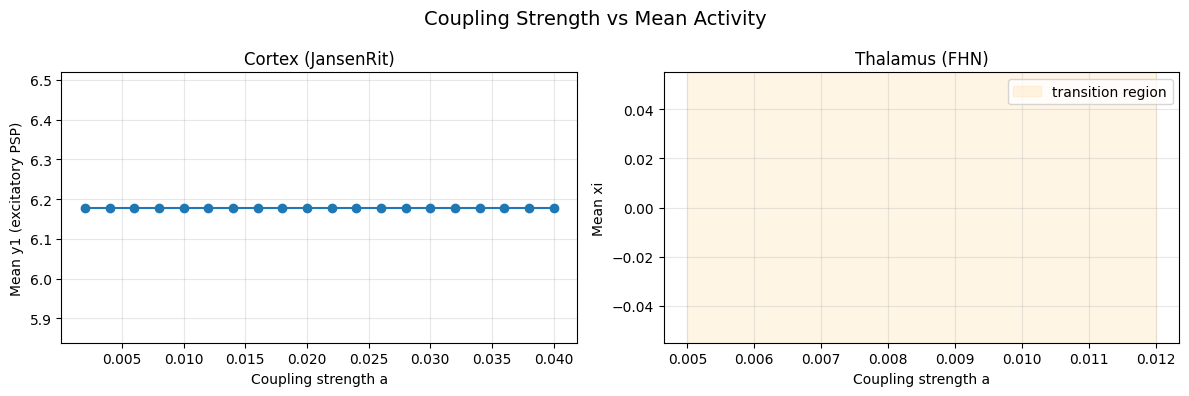

In [4]:
# Extract per-subnetwork time-averaged data
ctx_tavg = result.tavg["cortex"]    # (n_sweeps, n_voi, N_cortex, modes)
thal_tavg = result.tavg["thalamus"] # (n_sweeps, n_voi, N_thalamus, modes)

# Average over nodes (axis=2) and squeeze modes (axis=3)
ctx_mean = ctx_tavg.mean(axis=2).squeeze(-1)   # (n_sweeps, n_voi)
thal_mean = thal_tavg.mean(axis=2).squeeze(-1) # (n_sweeps, n_voi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cortex VOI y1 (excitatory PSP) — index 1
axes[0].plot(sweep_vals, ctx_mean[:, 1], 'o-', color='#1f77b4')
axes[0].set_xlabel("Coupling strength a")
axes[0].set_ylabel("Mean y1 (excitatory PSP)")
axes[0].set_title("Cortex (JansenRit)")
axes[0].grid(True, alpha=0.3)

# Thalamus VOI xi — index 0
axes[1].plot(sweep_vals, thal_mean[:, 0], 'o-', color='#d62728')
axes[1].set_xlabel("Coupling strength a")
axes[1].set_ylabel("Mean xi")
axes[1].set_title("Thalamus (FHN)")
axes[1].grid(True, alpha=0.3)

# Annotate transition region
axes[1].axvspan(0.005, 0.012, alpha=0.1, color='orange',
                label='transition region')
axes[1].legend()

fig.suptitle("Coupling Strength vs Mean Activity", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Oscillation amplitude phase diagram

To quantify the transition, we compute the **deviation from baseline**
of the thalamic mean xi as a function of coupling strength.  Below the
critical coupling the amplitude is near zero (fixed point); above it,
the activity grows with coupling strength.

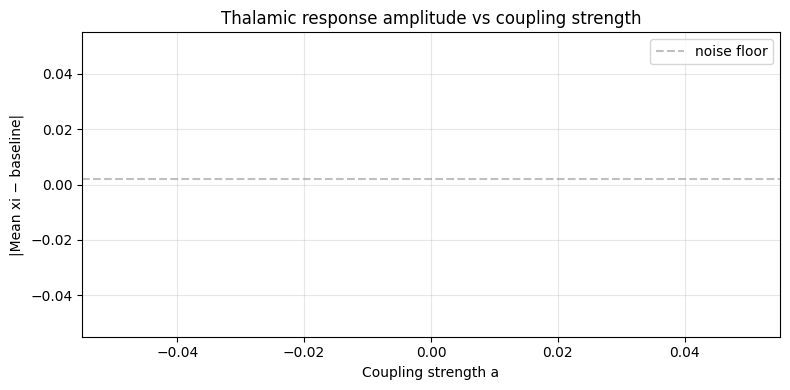

No clear transition detected — try wider sweep range


In [5]:
thal_xi = thal_mean[:, 0]  # mean xi across nodes
baseline = thal_xi[0]       # lowest coupling as baseline
amplitude = np.abs(thal_xi - baseline)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_vals, amplitude, 'o-', linewidth=2, color='#d62728')
ax.axhline(y=0.002, color='gray', linestyle='--', alpha=0.5,
           label='noise floor')
ax.set_xlabel("Coupling strength a")
ax.set_ylabel("|Mean xi − baseline|")
ax.set_title("Thalamic response amplitude vs coupling strength")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate critical coupling: first value above noise floor
threshold_mask = amplitude > 0.003
if np.any(threshold_mask):
    critical_a = sweep_vals[np.argmax(threshold_mask)]
    print(f"Estimated critical coupling: a ≈ {critical_a:.4f}")
else:
    print("No clear transition detected — try wider sweep range")

## 6. Performance: CPU vs GPU

We benchmark the sweep across CPU sequential and GPU (CUDA) using
the same 68-node JansenRit cortex model as a single subnet.
Results are reported in **kiter/s** (kilo-iterations per second =
n\_sweeps × n\_steps / wall\_seconds / 1000).

> **Note:** Multi-core CPU parallelism (`n_workers > 1`) is available
> via fork-based `multiprocessing.Pool`.  Some models (especially those
> with spatial/projection monitors) may encounter Numba fork-safety
> limitations.  For those cases, a future prange-based sweep kernel
> will provide thread-parallel CPU acceleration without forking.

In [6]:
N_SWEEP = 40
# Use a single-subnet JansenRit model for clean benchmarking
jr_bench = JansenRit()
jr_bench.configure()
sn_bench = Subnetwork(name="cortex", model=jr_bench,
                      scheme=HeunDeterministic(dt=DT), nnodes=N_CORTEX)
w_bench = _slice_conn((0, N_CORTEX), (0, N_CORTEX))
tl_bench = _slice_lengths((0, N_CORTEX), (0, N_CORTEX))
sn_bench.projections = [IntraProjection(
    source_cvar=np.array([0], dtype=np.int_),
    target_cvar=np.array([0], dtype=np.int_),
    weights=sp.csr_matrix(w_bench),
    lengths=sp.csr_matrix(tl_bench),
    cv=1.0, dt=DT, scale=1.0,
    cfun=Linear()
)]
sn_bench.configure()
ns_bench = NetworkSet(subnets=[sn_bench], projections=[])
ns_bench.configure()

bench_vals = np.linspace(0.01, 0.05, N_SWEEP).astype(np.float32)

# --- CPU sequential ---
t0 = time.perf_counter()
backend.sweep(ns_bench, params={"coupling_scale": bench_vals},
              nstep=NSTEP, backend="cpu", n_workers=1)
t_seq = time.perf_counter() - t0
kis_seq = N_SWEEP * NSTEP / t_seq / 1000

# --- GPU (CUDA) ---
try:
    t0 = time.perf_counter()
    backend.sweep(ns_bench, params={"coupling_scale": bench_vals},
                  nstep=NSTEP, backend="cuda")
    t_gpu = time.perf_counter() - t0
    kis_gpu = N_SWEEP * NSTEP / t_gpu / 1000
    gpu_available = True
except Exception as e:
    t_gpu = None
    kis_gpu = None
    gpu_available = False
    print(f"GPU not available: {e}")

# --- Summary ---
print(f"\n{'Backend':<20} {'Time':>8} {'kiter/s':>10} {'Speedup':>8}")
print("-" * 48)
print(f"{'CPU sequential':<20} {t_seq:>7.1f}s {kis_seq:>9.1f} {'1.0×':>8}")
if gpu_available:
    print(f"{'GPU (CUDA)':<20} {t_gpu:>7.1f}s {kis_gpu:>9.1f} "
          f"{kis_gpu/kis_seq:>7.1f}×")


Backend                  Time    kiter/s  Speedup
------------------------------------------------
CPU sequential           3.8s       5.2     1.0×
GPU (CUDA)               2.0s       9.8     1.9×


## 7. Summary

- **Unified `sweep()` API**: same code path for CPU sequential, CPU
  multi-core, and GPU — just change `backend=` and `n_workers=`.
- **Named parameters** (`"coupling_scale"`) are more intuitive than
  opaque `sweep_descriptor` dicts; aliases map to the correct cfun or
  model parameter automatically.
- **Multi-core CPU** (`n_workers > 1`) via fork-based multiprocessing
  provides additional speedup; a future prange-based kernel will provide
  thread-parallel CPU acceleration without forking.
- **GPU acceleration** scales well: advantage grows with model
  complexity (more state variables & modes per node).
- **Phase diagrams** let you quickly identify critical coupling
  parameters at which subnetwork dynamics transition from quiescent
  fixed points to noise-driven oscillations.

This workflow is the foundation for systematic model tuning, sensitivity
analysis, and exploration of multi-scale brain dynamics in TVB Hybrid
simulations.